In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [38]:
songs = pd.read_csv("Puja-clustered.csv", parse_dates=['date'])

In [39]:
icon = [col for col in songs.columns if col.startswith('icon_')]
weather_feat = ['temp', 'cloudcover']
audio_feat = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo']

In [40]:
X = songs[weather_feat + audio_feat + icon]
y = songs['cluster']

In [41]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42)

In [42]:
preprocessor = ColumnTransformer([
    ('numeric', MinMaxScaler(), weather_feat+audio_feat),
    ('bool', 'passthrough', icon)
])

In [43]:
model = make_pipeline(
    preprocessor,
    RandomForestClassifier(class_weight = 'balanced', random_state=42)
)

In [44]:
model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric', MinMaxScaler(),
                                                  ['temp', 'cloudcover',
                                                   'danceability', 'energy',
                                                   'key', 'loudness', 'mode',
                                                   'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'valence', 'tempo']),
                                                 ('bool', 'passthrough',
                                                  ['icon_clear-day',
                                                   'icon_cloudy',
                                                   'icon_partly-cloudy-day',
                                                   'icon_rain',
                                                   'icon_snow'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [45]:
model.score(X_valid, y_valid)

0.8973880597014925

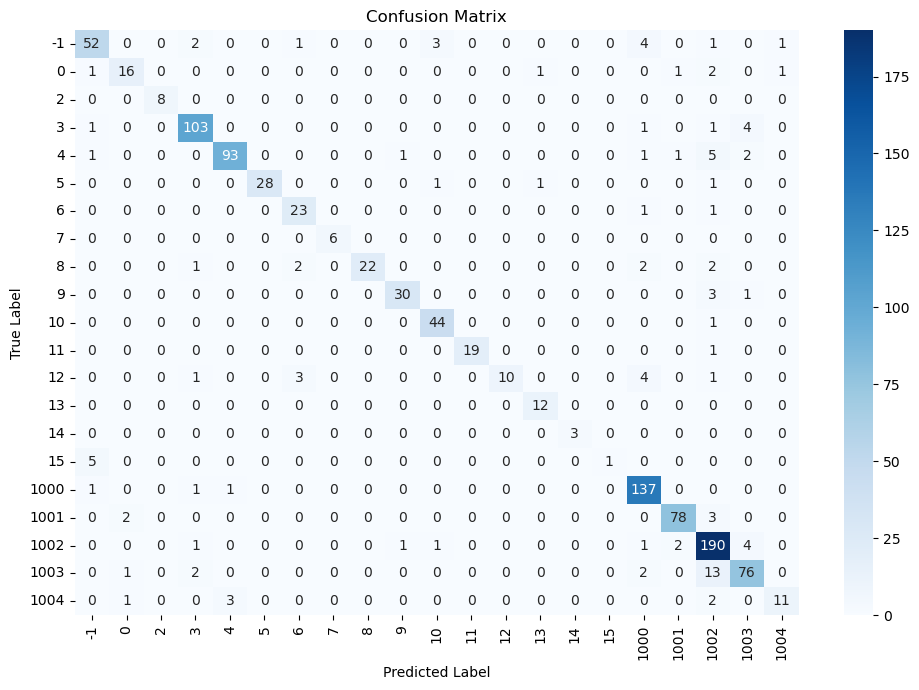

In [46]:
# Predict on the validation set
y_pred = model.predict(X_valid)

# Generate the confusion matrix
cm = confusion_matrix(y_valid, y_pred)
labels = np.unique(y_valid)  # Assumes your target labels are numeric or categorical

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Recommendation**

In [47]:
# reference date for the last ten day of listening history
last_day = pd.to_datetime('2025-02-28') # uses the last day in the dataset instead

In [48]:
last_ten_days = songs[songs['date'] > (last_day - pd.Timedelta(days=10))] # last ten days

In [49]:
audio_avg = last_ten_days[audio_feat].mean().values

*Sample Weather:* <br>
temp: 12 degree <br>
cloudcover: 83% <br>
icon: clear-day <br>

In [50]:
sample = pd.DataFrame(columns=weather_feat+icon+audio_feat)
sample.loc[1, weather_feat] = np.array([12.0, 83])
sample[icon] = False
sample['icon_clear-day'] = True
sample[audio_feat] = audio_avg

In [51]:
cluster = model.predict(sample)[0]

In [52]:
unique_songs = last_ten_days[last_ten_days['cluster'] == cluster]['track_history'].unique()

In [53]:
recommend = random.sample(list(unique_songs), 3)

In [54]:
print(f"Your three recommended songs based on weather and preferences are: {recommend}")

Your three recommended songs based on weather and preferences are: ['Monsters (feat. blackbear)', 'Kill Bill', 'Wait a Minute!']
